# RGP — Rigorous Gradation Pruning

Implements RGP (structured pruning with DFOT scoring and fine-tuning recovery) on ResNet50.
Designed to be run from `master.ipynb` which handles data/model loading.
Can also be run standalone by running all cells top to bottom.


In [1]:
import os, copy
import torch

# navigate to project root first — must happen before module imports
target = "CS6423_knowledge_distillation_project"
if not os.getcwd().endswith(target):
    import sys
    os.chdir(os.path.join(os.getcwd(), target))
    if os.getcwd() not in sys.path:
        sys.path.insert(0, os.getcwd())

print(f'Working dir: {os.getcwd()}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# now safe to import modules
import torch.nn as nn
import pandas as pd
from modules.model_trainer import modelTrainer
from modules.evaluate_model import ModelEvaluator


Working dir: /home/kod6/CS6423_knowledge_distillation_project
Device: cuda


In [2]:
from modules.dataset_prepper import datasetPrepper

data_prep = datasetPrepper(
    dataframe_path='data/labels.csv',
    image_dir='data/test_images',
).prepare(compute_class_weights=True)

CLASS_NAMES = data_prep.class_names
NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes: {NUM_CLASSES}')
print(f'Train batches: {len(data_prep.train_loader)} | Val batches: {len(data_prep.val_loader)}')


Classes: 61
Train batches: 249 | Val batches: 50


In [3]:
from modules.imagenet_loader import ImagenetLoader

WEIGHTS_PATH = 'trained_models/resnet50_baseline_gpu_new/resnet50_baseline_gpu_new.pth'

loader = ImagenetLoader()
resnet50 = loader.load_radimagenet_resnet50(
    weights_path=WEIGHTS_PATH,
    load_type='load'
)
loader.freeze_backbone()
resnet50 = resnet50.to(device)

print(f'ResNet50 loaded — {sum(p.numel() for p in resnet50.parameters()):,} params')


ResNet50 loaded — 23,633,021 params


In [4]:
evaluator = ModelEvaluator(
    data_loader=data_prep.val_loader,
    class_names=CLASS_NAMES,
    device=str(device)
)
baseline_metrics = evaluator.evaluate_single(resnet50, model_name='ResNet50_baseline')
BASELINE_F1 = baseline_metrics['f1_macro']

print(f'Baseline F1 macro:  {baseline_metrics["f1_macro"]:.4f}')
print(f'Baseline latency:   {baseline_metrics["avg_latency_ms"]:.2f} ms/sample')
print(f'Baseline size:      {baseline_metrics["model_size_mb"]:.2f} MB')



Warming up ResNet50_baseline...
Running inference...
Baseline F1 macro:  0.4867
Baseline latency:   1.14 ms/sample
Baseline size:      90.36 MB


In [5]:
import pandas as pd

# stub for standalone running — in master.ipynb these are defined in Cell 6
if 'results_df' not in dir():
    results_df = pd.DataFrame(columns=['Method', 'Base_Model', 'Size_Reduction_Pct', 'F1_Score'])
    def add_experiment(method, base_model, base_size, compressed_size, f1):
        global results_df
        size_reduction = round(((base_size - compressed_size) / base_size) * 100, 2)
        results_df = pd.concat([results_df, pd.DataFrame([{
            'Method': method,
            'Base_Model': base_model,
            'Size_Reduction_Pct': size_reduction,
            'F1_Score': f1
        }])], ignore_index=True)

# Kellie - RGP: Rigorous Gradient-based Pruning
#
# RGP iteratively removes the least important convolutional filters from ResNet50
# using gradient-based importance scores, shrinking the model in 5 steps from 10%
# to 50% sparsity. After each pruning step the model is fine-tuned to recover
# accuracy, trading off model size against F1 score across 5 Pareto front points.
#
# The process repeats 5 times, each time:
#   A. SCORE   - run a few training batches to measure which filters contribute
#                least to the loss using a gradient-based importance score (DFOT)
#   B. PRUNE   - permanently remove the lowest-scoring 10% of eligible filters,
#                also updating the next layer's input channels to match
#   C. RECOVER - fine-tune the pruned model for 10 epochs to regain accuracy
#
# After each iteration we log F1 and size reduction to the shared results_df,
# giving 5 data points on the Pareto front (10%, 20%, 30%, 40%, 50% sparsity).
#
# Protected layers (never pruned):
#   - conv3 layers (the final 1x1 conv in each ResNet50 bottleneck block)
#   - downsample layers (the skip connection projections)
#   - stem conv1 (the very first layer)
#   - conv2 in BasicBlock layers (ResNet18/10t) — output must match identity channels

import copy
import torch.nn as nn
from modules.model_trainer import modelTrainer

# --- 1. DFOT SCORER ---
class DFOTScorer:
    def __init__(self, model, alpha=0.5):
        self.model, self.alpha = model, alpha
        self._hooks, self._bufs, self._counts = [], {}, {}

    def register_hooks(self):
        for name, module in self.model.named_modules():
            if isinstance(module, nn.Conv2d):
                h = module.weight.register_hook(self._make_hook(name, module))
                self._hooks.append(h); self._bufs[name] = None; self._counts[name] = 0

    def _make_hook(self, name, module):
        def hook(grad):
            with torch.no_grad():
                raw = (module.weight.detach() * grad).abs().pow(self.alpha)
                f_scores = raw.view(raw.shape[0], -1).sum(dim=1)
                if self._bufs[name] is None: self._bufs[name] = f_scores.clone()
                else: self._bufs[name] += f_scores
                self._counts[name] += 1
        return hook

    def get_scores(self):
        return {n: (b / max(self._counts[n], 1)) for n, b in self._bufs.items() if b is not None}

    def remove_hooks(self):
        for h in self._hooks: h.remove()
        self._hooks = []


# --- 2. FILTER SELECTION ---
# Now takes model as argument to detect BasicBlock conv2 layers to protect

def get_filters_to_prune(scores, prune_ratio, protected_layers, pruning_mask, model=None):
    # identify BasicBlock conv2 layers to protect
    basicblock_conv2s = set()
    if model is not None:
        for name, module in model.named_modules():
            if hasattr(module, 'conv2') and not hasattr(module, 'conv3'):
                basicblock_conv2s.add(name + '.conv2')

    all_entries = []
    for layer_name, filter_scores in scores.items():
        if any(x in layer_name for x in ["conv3", "downsample"]) or layer_name in protected_layers:
            continue
        if layer_name in basicblock_conv2s:
            continue
        # protect stem layers — conv1 may be a Sequential in timm models
        if layer_name == "conv1" or layer_name.startswith("conv1."):
            continue
        already_pruned = pruning_mask.get(layer_name, [])
        for f_idx, score in enumerate(filter_scores.cpu().tolist()):
            if f_idx not in already_pruned:
                all_entries.append((score, layer_name, f_idx))
    all_entries.sort(key=lambda x: x[0])
    n_prune = int(len(all_entries) * prune_ratio)
    prune_map = {}
    for _, layer_name, f_idx in all_entries[:n_prune]:
        prune_map.setdefault(layer_name, []).append(f_idx)
    return prune_map


# --- 3. STRUCTURED PRUNING ---
def structured_prune(model, prune_map):

    def set_module(model, name, new_module):
        parts = name.split(".")
        parent = model
        for p in parts[:-1]: parent = getattr(parent, p)
        setattr(parent, parts[-1], new_module)

    def get_module(model, name):
        m = model
        for p in name.split("."): m = getattr(m, p)
        return m

    def prune_conv_out(conv, keep):
        new = nn.Conv2d(conv.in_channels, len(keep), conv.kernel_size,
                        stride=conv.stride, padding=conv.padding, bias=conv.bias is not None)
        with torch.no_grad():
            new.weight.copy_(conv.weight[keep])
            if conv.bias is not None: new.bias.copy_(conv.bias[keep])
        return new

    def prune_conv_in(conv, keep):
        new = nn.Conv2d(len(keep), conv.out_channels, conv.kernel_size,
                        stride=conv.stride, padding=conv.padding, bias=conv.bias is not None)
        with torch.no_grad():
            new.weight.copy_(conv.weight[:, keep, :, :])
            if conv.bias is not None: new.bias.copy_(conv.bias)
        return new

    def prune_bn(bn, keep):
        new = nn.BatchNorm2d(len(keep))
        with torch.no_grad():
            new.weight.copy_(bn.weight[keep])
            new.bias.copy_(bn.bias[keep])
            new.running_mean.copy_(bn.running_mean[keep])
            new.running_var.copy_(bn.running_var[keep])
        return new

    for layer_name, prune_indices in prune_map.items():
        if "conv3" in layer_name or "downsample" in layer_name:
            continue
        if layer_name == "conv1"or layer_name.startswith("conv1."):
            print(f"  Skipping stem conv1 — protected")
            continue

        try:
            conv = get_module(model, layer_name)
        except AttributeError:
            continue
        if not isinstance(conv, nn.Conv2d):
            continue

        keep = [i for i in range(conv.out_channels) if i not in prune_indices]
        if not keep:
            continue

        set_module(model, layer_name, prune_conv_out(conv, keep))

        # update corresponding BN
        bn_name = layer_name.replace("conv1", "bn1") if "conv1" in layer_name else \
                  layer_name.replace("conv2", "bn2") if "conv2" in layer_name else None
        if bn_name:
            try:
                bn = get_module(model, bn_name)
                if isinstance(bn, nn.BatchNorm2d):
                    set_module(model, bn_name, prune_bn(bn, keep))
            except AttributeError:
                pass

        # update next layer's input channels
        parts = layer_name.split(".")
        if len(parts) == 3:
            layer_group, block_idx, conv_num = parts
            next_name = f"{layer_group}.{block_idx}.conv2" if conv_num == "conv1" else \
                        f"{layer_group}.{block_idx}.conv3" if conv_num == "conv2" else None
            if next_name:
                try:
                    next_conv = get_module(model, next_name)
                    if isinstance(next_conv, nn.Conv2d):
                        set_module(model, next_name, prune_conv_in(next_conv, keep))
                except AttributeError:
                    pass

        pruning_mask[layer_name] = prune_indices

    total = sum(len(v) for v in pruning_mask.values())
    print(f"  Total filters removed: {total}")
    return model


# --- 4. MAIN EXECUTION LOOP ---

models_to_run = {
    'resnet50': {
        'weights': 'trained_models/resnet50_baseline_gpu_new/resnet50_baseline_gpu_new.pth',
        'loader_fn': loader.load_radimagenet_resnet50,
    },
    'resnet18': {
        'weights': 'trained_models/resnet18_baseline_gpu_new/resnet18_baseline_gpu_new.pth',
        'loader_fn': loader.load_radimagenet_resnet18,
    },
    'resnet10t': {
        'weights': 'trained_models/resnet10t_baseline_gpu_new/resnet10t_baseline_gpu_new.pth',
        'loader_fn': loader.load_radimagenet_resnet10t,
    },
}

for model_name, config in models_to_run.items():
    print(f"\n{'='*60}")
    print(f"Running RGP on {model_name}")
    print(f"{'='*60}")

    base_model = config['loader_fn'](
        weights_path=config['weights'],
        load_type='load'
    ).to(device)
    loader.freeze_backbone()

    rgp_model = copy.deepcopy(base_model).to(device)
    for p in rgp_model.parameters():
        p.requires_grad = True

    initial_params = sum(p.numel() for p in rgp_model.parameters())
    criterion      = nn.CrossEntropyLoss(weight=data_prep.class_weights.to(device))
    pruning_mask   = {}
    rgp_step_metrics = []

    for target in [0.10, 0.20, 0.30, 0.40, 0.50]:
        print(f"\n--- RGP Iteration: {target*100:.0f}% Sparsity ({model_name}) ---")

        # A. SCORE
        scorer = DFOTScorer(rgp_model)
        scorer.register_hooks()
        rgp_model.train()
        for i, (imgs, labels) in enumerate(data_prep.train_loader):
            if i >= 15: break
            loss = criterion(rgp_model(imgs.to(device)), labels.to(device))
            loss.backward()

        # B. PRUNE
        scores    = scorer.get_scores()
        scorer.remove_hooks()
        prune_map = get_filters_to_prune(scores, 0.10, [], pruning_mask, model=rgp_model)
        rgp_model = structured_prune(rgp_model, prune_map)

        # C. RECOVER
        trainer = modelTrainer(
            model=rgp_model,
            data_prep=data_prep,
            device=device,
            learn_rate=2e-4,
            num_epochs=10,
            model_name=f"{model_name}_rgp_step_{target}"
        )
        trainer.prepare_for_training()
        trainer.train_all(save_as_object=True)

        step_metrics = evaluator.evaluate_single(rgp_model, f"{model_name}_RGP_{int(target*100)}pct")
        step_params  = sum(p.numel() for p in rgp_model.parameters())

        add_experiment(
            method='RGP',
            base_model=model_name,
            base_size=initial_params,
            compressed_size=step_params,
            f1=step_metrics['f1_macro']
        )

        rgp_step_metrics.append({
            'Sparsity': f"{int(target*100)}%",
            'Size Reduction (%)': round(((initial_params - step_params) / initial_params) * 100, 2),
            'F1 Score': round(step_metrics['f1_macro'], 4),
            'Size (MB)': round(step_metrics['model_size_mb'], 1),
            'Latency (ms)': round(step_metrics['avg_latency_ms'], 2),
        })

    print(f"\n--- {model_name} RGP Results ---")
    summary_df = pd.DataFrame(rgp_step_metrics).set_index('Sparsity')
    summary_df.index.name = 'RGP Step'
    display(summary_df)


Running RGP on resnet50

--- RGP Iteration: 10% Sparsity (resnet50) ---
  Total filters removed: 627


Validating: 100%|██████████| 50/50 [00:03<00:00, 15.96batch/s]



Epoch 1/10
Train Loss: 1.1778 | Train F1: 0.3872
Val Loss: 2.1563 | Val F1: 0.2870
Epoch Time: 35.44s



Validating: 100%|██████████| 50/50 [00:03<00:00, 15.13batch/s]



Epoch 2/10
Train Loss: 0.7517 | Train F1: 0.4606
Val Loss: 1.9818 | Val F1: 0.3033
Epoch Time: 36.45s



...


Epoch 9/10
Train Loss: 0.2809 | Train F1: 0.6427
Val Loss: 2.4473 | Val F1: 0.2746
Epoch Time: 27.08s



Validating: 100%|██████████| 50/50 [00:02<00:00, 19.51batch/s]


Epoch 10/10
Train Loss: 0.2784 | Train F1: 0.6389
Val Loss: 2.4651 | Val F1: 0.2679
Epoch Time: 26.04s


Warming up resnet10t_RGP_50pct...


Running inference...

--- resnet10t RGP Results ---


,Size Reduction (%),F1 Score,Size (MB),Latency (ms)
RGP Step,,,,
10%,3.27,0.2982,18.3,0.33
20%,8.41,0.2963,17.3,0.31
30%,16.06,0.3076,15.9,0.32
40%,21.69,0.2838,14.8,0.31
50%,27.60,0.2679,13.7,0.30


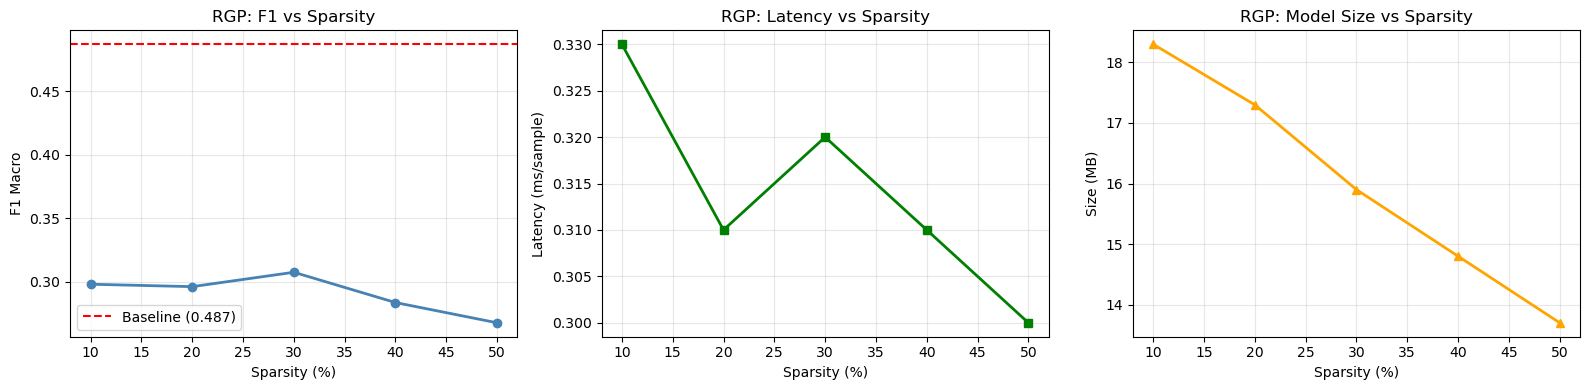

Saved → rgp_checkpoints/rgp_results.png


In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sparsities = [float(m['Sparsity'].strip('%')) for m in rgp_step_metrics]
f1s        = [m['F1 Score'] for m in rgp_step_metrics]
latencies  = [m['Latency (ms)'] for m in rgp_step_metrics]
sizes      = [m['Size (MB)'] for m in rgp_step_metrics]

axes[0].plot(sparsities, f1s, 'o-', color='steelblue', lw=2)
axes[0].axhline(BASELINE_F1, color='red', linestyle='--', label=f'Baseline ({BASELINE_F1:.3f})')
axes[0].set_xlabel('Sparsity (%)'); axes[0].set_ylabel('F1 Macro')
axes[0].set_title('RGP: F1 vs Sparsity'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(sparsities, latencies, 's-', color='green', lw=2)
axes[1].set_xlabel('Sparsity (%)'); axes[1].set_ylabel('Latency (ms/sample)')
axes[1].set_title('RGP: Latency vs Sparsity'); axes[1].grid(True, alpha=0.3)

axes[2].plot(sparsities, sizes, '^-', color='orange', lw=2)
axes[2].set_xlabel('Sparsity (%)'); axes[2].set_ylabel('Size (MB)')
axes[2].set_title('RGP: Model Size vs Sparsity'); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs('rgp_checkpoints', exist_ok=True)
plt.savefig('rgp_checkpoints/rgp_results.png', dpi=150)
plt.show()
print('Saved → rgp_checkpoints/rgp_results.png')
